# Laboratory #4: Adversarial Learning and OOD Detection

In this laboratory session we will develop a methodology for detecting OOD samples and measuring the quality of OOD detection. We will also experiment with incorporating adversarial examples during training to render models more robust to adversarial attacks.

---
## Exercise 1: OOD Detection and Performance Evaluation
In this first exercise you will build a simple OOD detection pipeline and implement some performance metrics to evaluate its performance.

### Exercise 1.1: Build a simple OOD detection pipeline

Implement an OOD detection pipeline (like in the Flipped Activity notebook) using an ID and an OOD dataset of your choice. Some options:

+ CIFAR-10 (ID), Subset of CIFAR-100 (OOD). You will need to wrap CIFAR-100 in some way to select a subset of classes that are *not* in CIFAR-10 (see `torch.utils.data.Subset`).
+ Labeled Faces in the Wild (ID), CIFAR-10 or FakeData (OOD). The LfW dataset is available in Scikit-learn (see `sklearn.datasets.fetch_lfw_people`).
+ Something else, but if using images keep the images reasonably small!

In this exercise your *OOD Detector* should produce a score representing how "out of distribution" a test sample is. We will implement some metrics in the next exercise, but for now use the techniques from the flipped activity notebook to judge how well OOD scoring is working (i.e. histograms).

**Note**: Make sure you make a validation split of your ID dataset for testing.

In [1]:
# --- 1. Setup ---
import os
import json
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision import transforms
from torch.utils.data import Subset, random_split
import matplotlib.pyplot as plt

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [2]:
# --- 2. Model definition ---
# Must match EXACTLY the architecture used to produce the provided checkpoints
# (same as the professor's Flipped Activity notebook), otherwise load_state_dict fails.
class CNN(nn.Module):
    def __init__(self, dropout=False):
        super().__init__()
        self.dropout = dropout
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(128, 128, kernel_size=3, stride=2, padding=1)  # downsample
        self.conv5 = nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1)  # downsample

        self.flatten_dim = 256 * 8 * 8  # assuming input is 32x32
        self.fc1 = nn.Linear(self.flatten_dim, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = F.relu(self.conv4(x))
        x = F.relu(self.conv5(x))
        x = torch.flatten(x, 1)
        if self.dropout:
            x = F.dropout(F.relu(self.fc1(x)))
            x = F.dropout(F.relu(self.fc2(x)))
        else:
            x = F.relu(self.fc1(x))
            x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [3]:
# --- 3. ID dataset: CIFAR-10, with train/val/test split ---
# Two separate, coexisting transforms and train loaders (plain vs augmented),
# so both versions stay available and reproducible at any time -- nothing
# gets overwritten, no matter which one you train/retrain later.
batch_size = 128

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])
eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

# Two "views" of the same underlying CIFAR-10 train data.
id_train_full_aug = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=train_transform)
id_train_full_plain = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=eval_transform)
id_test = torchvision.datasets.CIFAR10(root="./data", train=False, download=True, transform=eval_transform)

val_size = int(0.1 * len(id_train_full_aug))
train_size = len(id_train_full_aug) - val_size

# Same seed on both views -> identical index partition (which images go to
# train vs val is the same either way), only the transform attached differs.
generator = torch.Generator().manual_seed(SEED)
id_train_aug, _ = random_split(id_train_full_aug, [train_size, val_size], generator=generator)

generator2 = torch.Generator().manual_seed(SEED)
id_train_plain, id_val = random_split(id_train_full_plain, [train_size, val_size], generator=generator2)

# Two independent, coexisting train loaders.
id_train_loader_plain = torch.utils.data.DataLoader(id_train_plain, batch_size=batch_size, shuffle=True, num_workers=4)
id_train_loader_aug = torch.utils.data.DataLoader(id_train_aug, batch_size=batch_size, shuffle=True, num_workers=4)

# Validation and test are never augmented, regardless of which train loader
# you use -- there is only ever one id_val_loader / id_test_loader.
id_val_loader = torch.utils.data.DataLoader(id_val, batch_size=batch_size, shuffle=False)
id_test_loader = torch.utils.data.DataLoader(id_test, batch_size=batch_size, shuffle=False)

print(f"ID train (plain): {len(id_train_plain)}, ID train (aug): {len(id_train_aug)}, ID val: {len(id_val)}, ID test: {len(id_test)}")

ID train (plain): 45000, ID train (aug): 45000, ID val: 5000, ID test: 10000


In [4]:
# --- 4. OOD dataset: a "far" subset of CIFAR-100 ---
# We pick CIFAR-100 fine classes with NO semantic overlap with any CIFAR-10
# class (CIFAR-10 = airplane, automobile, bird, cat, deer, dog, frog, horse,
# ship, truck -- i.e. only vehicles and animals). We deliberately avoid all
# CIFAR-100 animal/vehicle classes and pick from clearly unrelated categories
# (flowers, food containers, man-made outdoor structures).
cifar100_full = torchvision.datasets.CIFAR100(root="./data", train=False, download=True, transform=eval_transform)

FAR_OOD_CLASSES = [
    "orchid", "poppy", "rose", "sunflower", "tulip",          # flowers
    "bottle", "bowl", "can", "cup", "plate",                   # food containers
    "bridge", "castle", "house", "road", "skyscraper",         # large man-made outdoor things
]
far_ood_indices = [cifar100_full.class_to_idx[c] for c in FAR_OOD_CLASSES]

ood_indices = [i for i, (_, label) in enumerate(cifar100_full) if label in far_ood_indices]
ood_dataset = Subset(cifar100_full, ood_indices)
ood_loader = torch.utils.data.DataLoader(ood_dataset, batch_size=batch_size, shuffle=False)

print(f"OOD samples (far subset of CIFAR-100): {len(ood_dataset)}")

OOD samples (far subset of CIFAR-100): 1500


In [5]:
def train_cnn(train_loader, dropout: bool, epochs: int = 50, lr: float = 1e-4):
    model = CNN(dropout=dropout).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    history = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for x, y in train_loader:   # <-- ora un parametro, non più una variabile esterna
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        if (epoch + 1) % 10 == 0 or epoch == epochs - 1:
            model.eval()
            correct, total = 0, 0
            with torch.no_grad():
                for x, y in id_val_loader:
                    x, y = x.to(device), y.to(device)
                    preds = model(x).argmax(dim=1)
                    correct += (preds == y).sum().item()
                    total += y.size(0)
            val_acc = correct / total
            train_loss = running_loss / len(train_loader)
            history.append({"epoch": epoch + 1, "train_loss": train_loss, "val_acc": val_acc})
            print(f"Epoch {epoch+1}/{epochs} - train loss: {train_loss:.4f} - val acc: {val_acc:.4f}")

    return model, history


def get_model(train_loader, dropout: bool, checkpoint_path: str, epochs: int = 50, lr: float = 1e-4):
    model = CNN(dropout=dropout)
    history_path = checkpoint_path.replace(".pth", "_history.json")

    if os.path.exists(checkpoint_path):
        print(f"Found existing checkpoint at {checkpoint_path}, loading it.")
        model.load_state_dict(torch.load(checkpoint_path, map_location=device))
        model = model.to(device)
        if os.path.exists(history_path):
            with open(history_path) as f:
                history = json.load(f)
            for h in history:
                print(f"Epoch {h['epoch']}/{epochs} - train loss: {h['train_loss']:.4f} - val acc: {h['val_acc']:.4f}")
    else:
        print(f"No checkpoint found at {checkpoint_path}, training from scratch.")
        model, history = train_cnn(train_loader, dropout=dropout, epochs=epochs, lr=lr)
        torch.save(model.state_dict(), checkpoint_path)
        with open(history_path, "w") as f:
            json.dump(history, f)

    return model

In [13]:
# --- 5. Original (no augmentation) ---
cnn_baseline = get_model(id_train_loader_plain, dropout=False, checkpoint_path="checkpoints/cnn_baseline.pth")
cnn_dropout = get_model(id_train_loader_plain, dropout=True, checkpoint_path="checkpoints/cnn_dropout.pth")

Found existing checkpoint at checkpoints/cnn_baseline.pth, loading it.
Epoch 10/50 - train loss: 0.8133 - val acc: 0.6418
Epoch 20/50 - train loss: 0.1180 - val acc: 0.6386
Epoch 30/50 - train loss: 0.0266 - val acc: 0.6358
Epoch 40/50 - train loss: 0.0325 - val acc: 0.6424
Epoch 50/50 - train loss: 0.0215 - val acc: 0.6338
Found existing checkpoint at checkpoints/cnn_dropout.pth, loading it.
Epoch 10/50 - train loss: 1.1720 - val acc: 0.5774
Epoch 20/50 - train loss: 0.7681 - val acc: 0.6346
Epoch 30/50 - train loss: 0.4557 - val acc: 0.6572
Epoch 40/50 - train loss: 0.2823 - val acc: 0.6594
Epoch 50/50 - train loss: 0.2080 - val acc: 0.6652


In [14]:
# --- 5bis. Augmented variants ---
cnn_baseline_aug = get_model(id_train_loader_aug, dropout=False, checkpoint_path="checkpoints/cnn_baseline_aug.pth", epochs=100)
cnn_dropout_aug = get_model(id_train_loader_aug, dropout=True, checkpoint_path="checkpoints/cnn_dropout_aug.pth", epochs=100)

No checkpoint found at checkpoints/cnn_baseline_aug.pth, training from scratch.
Epoch 10/100 - train loss: 1.2208 - val acc: 0.5820
Epoch 20/100 - train loss: 0.9485 - val acc: 0.6746
Epoch 30/100 - train loss: 0.7890 - val acc: 0.7086
Epoch 40/100 - train loss: 0.6767 - val acc: 0.7410
Epoch 50/100 - train loss: 0.5872 - val acc: 0.7568
Epoch 60/100 - train loss: 0.5179 - val acc: 0.7706
Epoch 70/100 - train loss: 0.4487 - val acc: 0.7756
Epoch 80/100 - train loss: 0.4007 - val acc: 0.7776
Epoch 90/100 - train loss: 0.3543 - val acc: 0.7858
Epoch 100/100 - train loss: 0.3118 - val acc: 0.7862
No checkpoint found at checkpoints/cnn_dropout_aug.pth, training from scratch.
Epoch 10/100 - train loss: 1.3810 - val acc: 0.5372
Epoch 20/100 - train loss: 1.1510 - val acc: 0.6108
Epoch 30/100 - train loss: 1.0108 - val acc: 0.6652
Epoch 40/100 - train loss: 0.9068 - val acc: 0.7080
Epoch 50/100 - train loss: 0.8176 - val acc: 0.7348
Epoch 60/100 - train loss: 0.7455 - val acc: 0.7588
Epoch 70

[baseline] ID scores  -- mean: 0.9397, std: 0.1247
[baseline] OOD scores -- mean: 0.9092, std: 0.1456


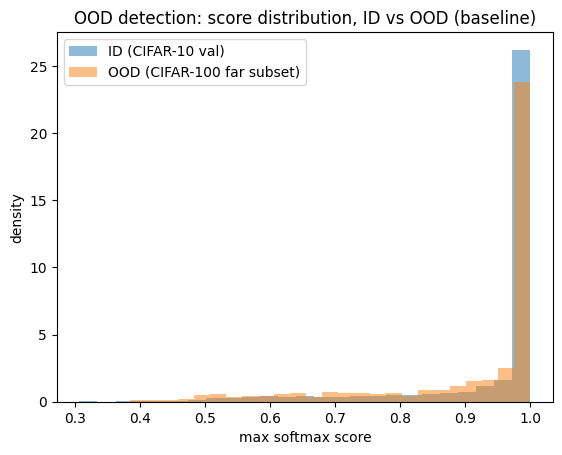

[dropout] ID scores  -- mean: 0.8894, std: 0.1729
[dropout] OOD scores -- mean: 0.7695, std: 0.2149


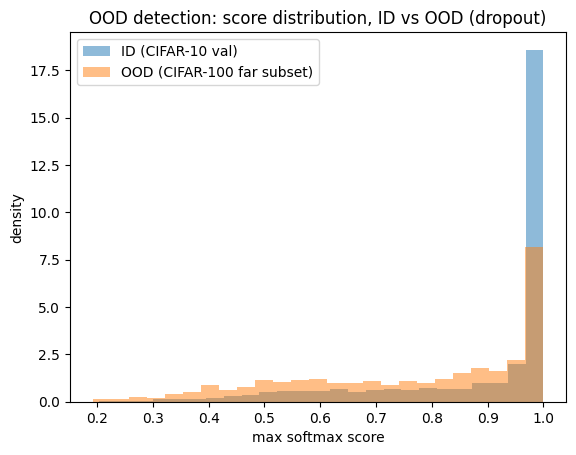

[baseline_aug] ID scores  -- mean: 0.8831, std: 0.1705
[baseline_aug] OOD scores -- mean: 0.7644, std: 0.2021


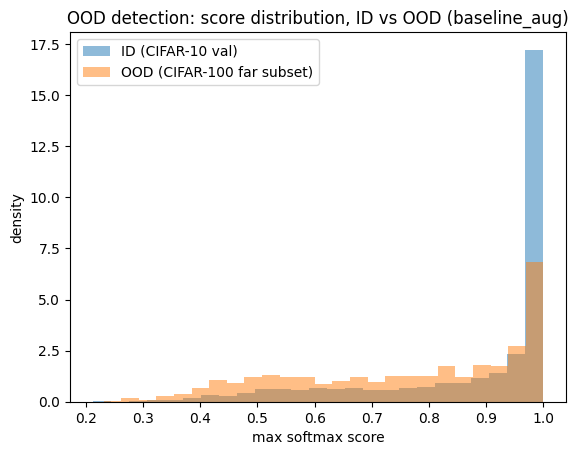

[dropout_aug] ID scores  -- mean: 0.8502, std: 0.1960
[dropout_aug] OOD scores -- mean: 0.6430, std: 0.2183


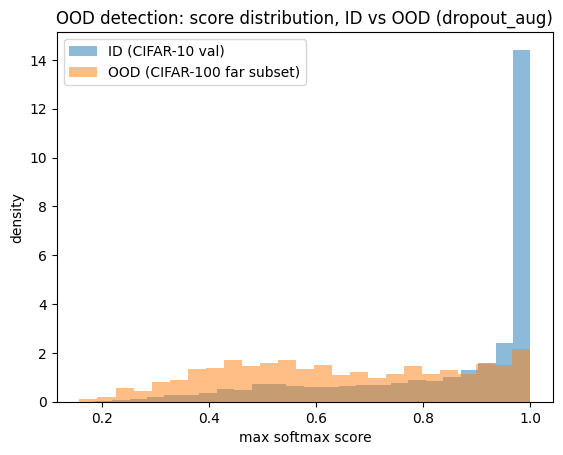

In [15]:
# --- 6. OOD scores for all four models ---

def max_logit(logit):
    return logit.max(dim=1)[0]

def max_softmax(logit, T=1.0):
    s = F.softmax(logit / T, dim=1)
    return s.max(dim=1)[0]

def compute_scores(data_loader, score_fun, model):
    scores = []
    model.eval()
    with torch.no_grad():
        for x, y in data_loader:
            output = model(x.to(device))
            scores.append(score_fun(output))
    return torch.cat(scores)

models = {
    "baseline": cnn_baseline,
    "dropout": cnn_dropout,
    "baseline_aug": cnn_baseline_aug,
    "dropout_aug": cnn_dropout_aug,
}

# Disable the stochastic dropout-at-inference behavior on every model that
# has it, for this standard single-pass evaluation (model.eval() alone isn't
# enough -- see earlier note on CNN.forward() calling F.dropout directly).
for name, model in models.items():
    if hasattr(model, "dropout"):
        model.dropout = False

scores = {}
for name, model in models.items():
    id_scores = compute_scores(id_val_loader, max_softmax, model)
    ood_scores = compute_scores(ood_loader, max_softmax, model)
    scores[name] = (id_scores, ood_scores)

    print(f"[{name}] ID scores  -- mean: {id_scores.mean():.4f}, std: {id_scores.std():.4f}")
    print(f"[{name}] OOD scores -- mean: {ood_scores.mean():.4f}, std: {ood_scores.std():.4f}")

    plt.hist(id_scores.cpu(), density=True, alpha=0.5, bins=25, label="ID (CIFAR-10 val)")
    plt.hist(ood_scores.cpu(), density=True, alpha=0.5, bins=25, label="OOD (CIFAR-100 far subset)")
    plt.xlabel("max softmax score")
    plt.ylabel("density")
    plt.legend()
    plt.title(f"OOD detection: score distribution, ID vs OOD ({name})")
    plt.show()

### Exercise 1.2: Measure your OOD detection performance

There are several metrics used to evaluate OOD detection performance, we will concentrate on two threshold-free approaches: the area under the Receiver Operator Characteristic (ROC) curve for ID classification, and the area under the Precision-Recall curve for *both* ID and OOD scoring. See [the ODIN paper](https://arxiv.org/pdf/1706.02690.pdf) section 4.3 for a description of OOD metrics.

Use the functions in `sklearn.metrics` to produce ROC and PR curves for your OOD detector. Some useful functions:

+ [`sklearn.metric.RocCurveDisplay.from_predictions`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.RocCurveDisplay.html)
+ [`sklearn.metrics.PrecisionRecallDisplay`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.PrecisionRecallDisplay.html)


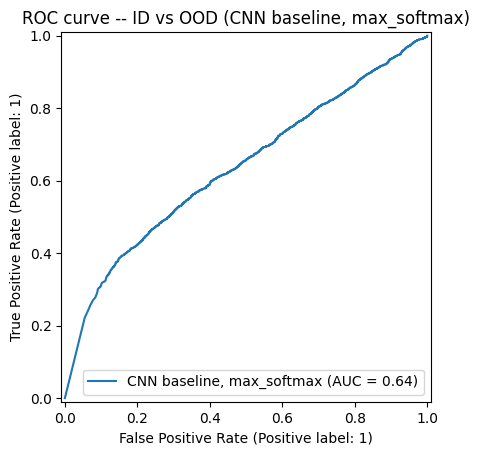

[CNN baseline, max_softmax] AUROC: 0.6369


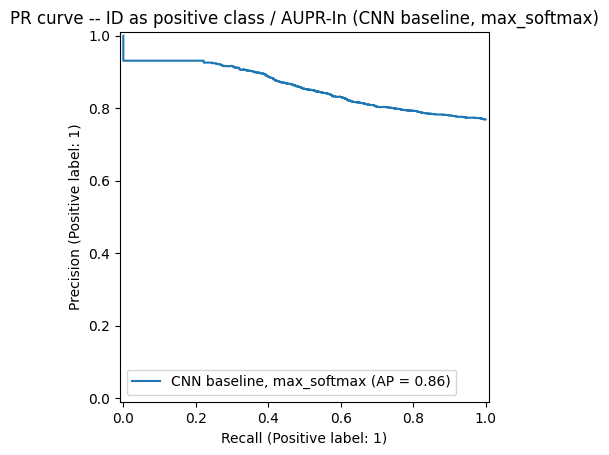

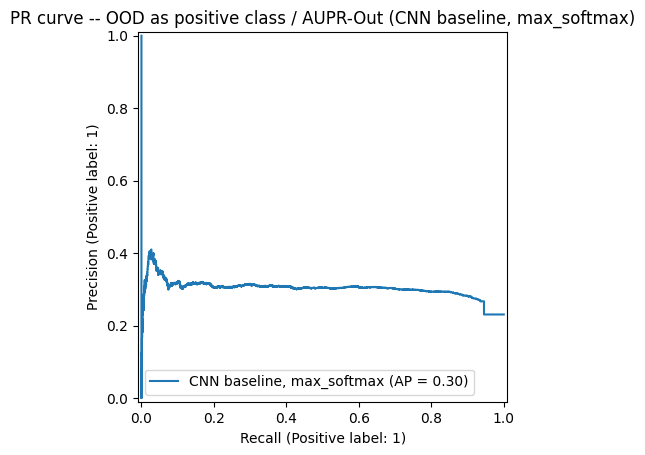

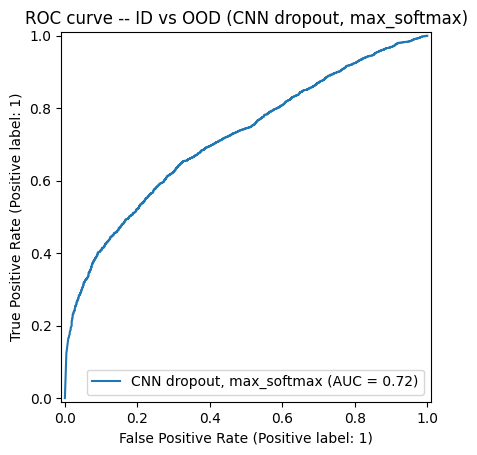

[CNN dropout, max_softmax] AUROC: 0.7175


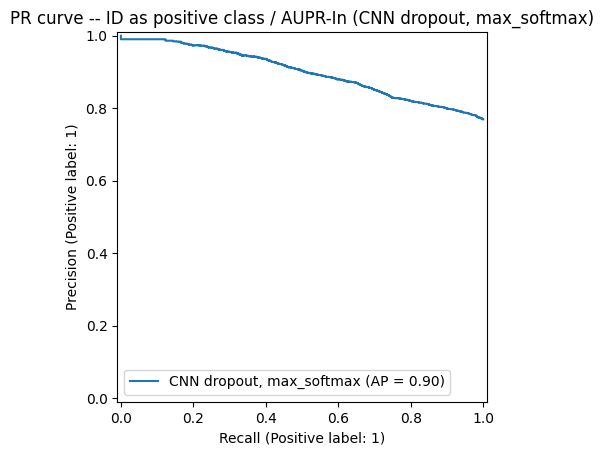

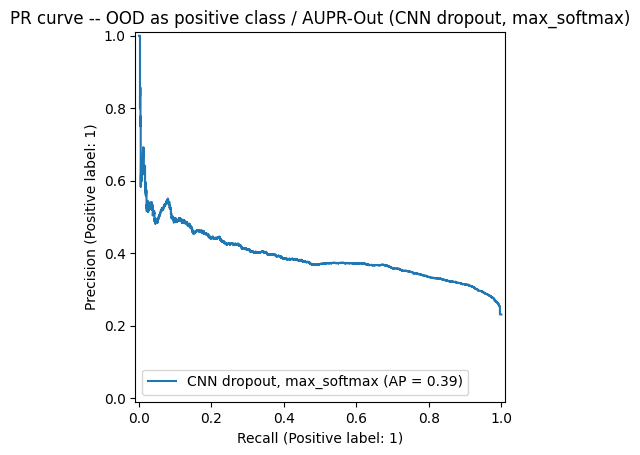

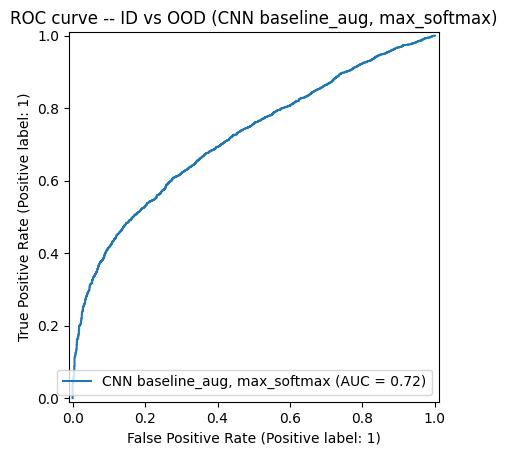

[CNN baseline_aug, max_softmax] AUROC: 0.7175


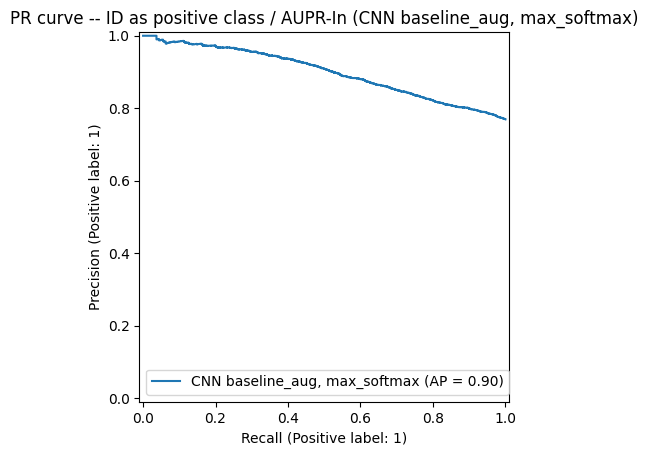

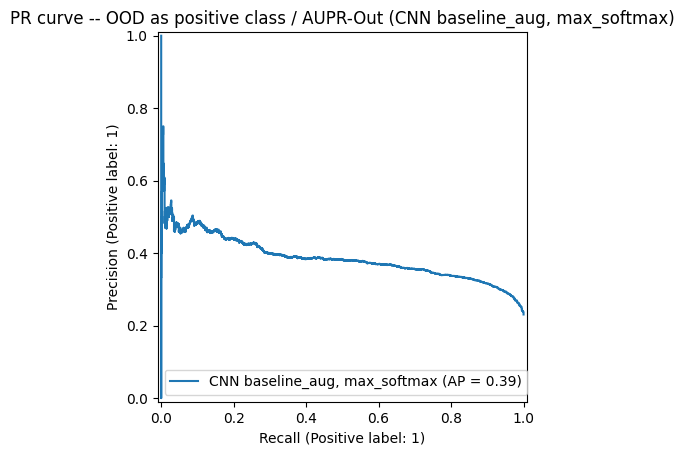

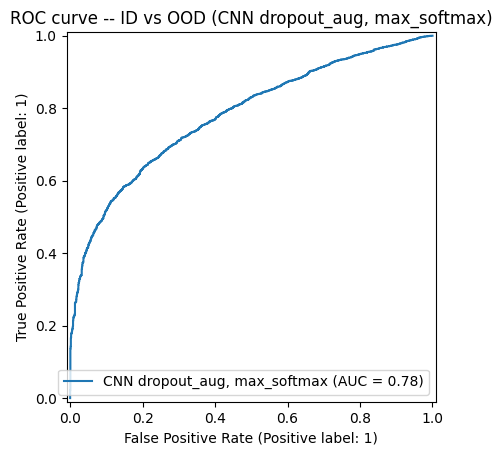

[CNN dropout_aug, max_softmax] AUROC: 0.7813


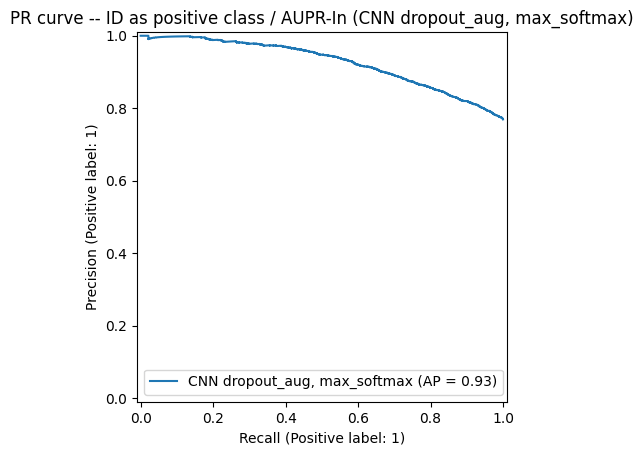

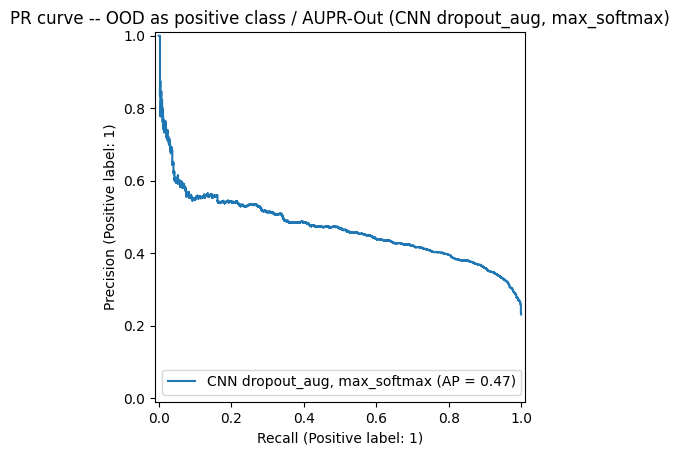

In [16]:
# --- Exercise 1.2: OOD detection metrics (ROC / PR curves) ---
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay, roc_auc_score

def evaluate_ood_detection(id_scores, ood_scores, label=""):
    """
    Given ID and OOD scores (higher score = more confidently in-distribution),
    plots the ROC curve and both PR curves (ID-positive and OOD-positive),
    and prints AUROC.
    """
    id_scores = id_scores.cpu().numpy()
    ood_scores = ood_scores.cpu().numpy()

    # Convention: label 1 = ID, label 0 = OOD. A higher score should mean
    # "more confidently ID" -- exactly what max_softmax/max_logit give us.
    y_true = np.concatenate([np.ones_like(id_scores), np.zeros_like(ood_scores)])
    y_score = np.concatenate([id_scores, ood_scores])

    # --- ROC curve: can we tell ID from OOD at all? ---
    RocCurveDisplay.from_predictions(y_true, y_score, name=label)
    plt.title(f"ROC curve -- ID vs OOD ({label})")
    plt.show()
    print(f"[{label}] AUROC: {roc_auc_score(y_true, y_score):.4f}")

    # --- PR curve, ID as positive class (AUPR-In) ---
    PrecisionRecallDisplay.from_predictions(y_true, y_score, name=label)
    plt.title(f"PR curve -- ID as positive class / AUPR-In ({label})")
    plt.show()

    # --- PR curve, OOD as positive class (AUPR-Out) ---
    # Swapping which class is "positive" also requires flipping the score:
    # a higher score must now mean "more confidently OOD" -- so we negate it.
    # (This is why AUPR-In and AUPR-Out are reported separately in the ODIN
    # paper: unlike ROC, PR curves are NOT symmetric under this swap.)
    y_true_ood = 1 - y_true
    y_score_ood = -y_score
    PrecisionRecallDisplay.from_predictions(y_true_ood, y_score_ood, name=label)
    plt.title(f"PR curve -- OOD as positive class / AUPR-Out ({label})")
    plt.show()


for name, (id_scores, ood_scores) in scores.items():
    evaluate_ood_detection(id_scores, ood_scores, label=f"CNN {name}, max_softmax")

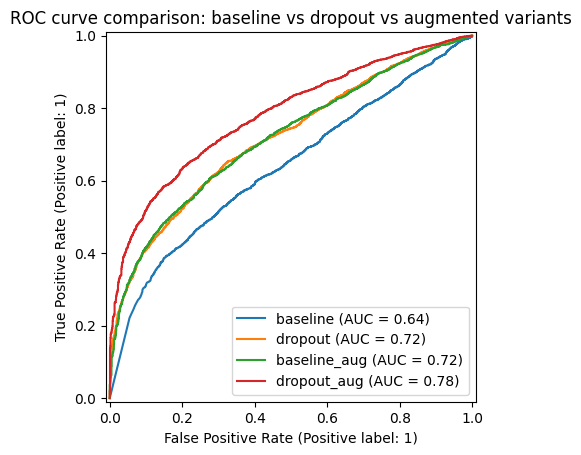

In [17]:
# --- Direct comparison: all four models on the same ROC axes ---
fig, ax = plt.subplots()
for name, (id_scores, ood_scores) in scores.items():
    y_true = np.concatenate([np.ones(len(id_scores)), np.zeros(len(ood_scores))])
    y_score = np.concatenate([id_scores.cpu().numpy(), ood_scores.cpu().numpy()])
    RocCurveDisplay.from_predictions(y_true, y_score, name=name, ax=ax)
plt.title("ROC curve comparison: baseline vs dropout vs augmented variants")
plt.show()

## Considerations

Extending training from 50 to 100 epochs for the augmented variants revealed
that our first conclusions were partly premature: `baseline_aug` had already
plateaued at 50 epochs (+0.8pp accuracy with 50 more epochs, and its AUROC
actually *decreased* slightly as the model grew more confident on both ID and
OOD inputs alike), while `dropout_aug` was still clearly under-trained
(+9.1pp accuracy, AUROC improving from 0.741 to 0.781).

With adequate training, the earlier dissociation between "best classifier"
and "best OOD detector" disappears: `dropout_aug` is now the best model on
*both* fronts (79.6% validation accuracy, 0.781 AUROC), rather than trading
one off against the other. This is a useful reminder that conclusions drawn
from an under-trained checkpoint can be misleading -- what looked like a
genuine trade-off was, at least in part, an artifact of comparing models at
different stages of convergence.

Looking at all four models together, AUROC improves monotonically with each
added source of regularization: baseline (0.637) < dropout ≈ baseline_aug
(0.7175, an exact tie) < dropout_aug (0.781). Both dropout and data
augmentation independently improve OOD separability, and stacking them
(given enough training time) compounds the effect rather than cancelling
it out.

Even at its best, however, absolute AUROC remains moderate (0.78, not close
to 1.0): the score histograms show max-softmax still saturates near 1.0 for
a meaningful fraction of OOD inputs, a known overconfidence issue with this
scoring function. This motivates exploring temperature scaling (Exercise 3.1
 ODIN) as a way to further improve separation without retraining the
classifier.

---
## Exercise 2: Enhancing Robustness to Adversarial Attack

In this second exercise we will experiment with enhancing our base model to be (more) robust to adversarial attacks. 

### Exercise 2.1: Implement FGSM and generate adversarial examples

Recall that the Fast Gradient Sign Method (FGSM) perturbs samples in the direction of the gradient with respect to the input $\mathbf{x}$:
$$ \boldsymbol{\eta}(\mathbf{x}) = \varepsilon \mathrm{sign}(\nabla_{\mathbf{x}} \mathcal{L}(\boldsymbol{\theta}, \mathbf{x}, y)) ) $$
Implement FGSM and generate some *adversarial examples* using your trained ID model. Evaluate these samples qualitatively and quantitatively. Evaluate how dependent on $\varepsilon$ the quality of these samples are. 

In [11]:
# Your code here.

### Exercise 2.2: Augment training with adversarial examples

Use your implementation of FGSM to augment your training dataset with adversarial samples. Ideally, you should implement this data augmentation *on the fly* so that the adversarial samples are always generated using the current model. Evaluate whether the model is more (or less) robust to ID samples using your OOD detection pipeline and metrics you implemented in Exercise 1.

In [12]:
# Your code here.

---
## Exercise 3: Wildcard

You know the drill. Pick *ONE* of the following exercises to complete.

### Exercise 3.1: Implement ODIN for OOD detection
ODIN is a very simple approach, and you can already start experimenting by implementing a temperature hyperparameter in your base model and doing a grid search on $T$ and $\varepsilon$.

### Exercise 3.2: Implement JARN
In exercise 2.2 you already implemented Jacobian-regularized learning to make your model more robust to adversarial samples. Add a *discriminator* to your model to encourage the adversarial samples used for regularization to be more *salient*.

See [the JARN paper](https://arxiv.org/abs/1912.10185) for more details.

### Exercise 3.3: Experiment with *targeted* adversarial attacks
Implement the targeted Fast Gradient Sign Method to generate adversarial samples that *imitate* samples from a specific class. Evaluate your adversarial samples qualitatively and quantitatively.
